# Bài toán: Phân cụm hành vi của chuyến xe taxi trong NYC

## Thành viên:
* Huỳnh Anh Nhựt
* Nguyễn Tiến Minh
* Huỳnh Anh Tuấn

Không phải tất cả các chuyến taxi trong thành phố New York đều có đặc điểm giống nhau. 

Một số chuyến đi có khoảng cách ngắn nhưng thời gian di chuyển dài do tình trạng ùn tắc giao thông, trong khi một số chuyến khác có khoảng cách xa nhưng tốc độ cao nhờ di chuyển trên các tuyến đường cao tốc hoặc kết nối sân bay.

Ngoài ra, hành vi di chuyển của hành khách cũng thay đổi theo thời gian trong ngày, khoảng cách chuyến đi và mức chi phí.

Do đó, việc phân cụm các chuyến taxi theo hành vi di chuyển có thể giúp:
- Hiểu rõ quy luật dẫn đến hành vi của các chuyến xe 
- Nắm được nhu cầu khách hàng 
- Tối ưu phân bổ tài xế hợp lý

## Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from taxi_preprocessing import drop_features
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load dữ liệu

In [2]:
taxi_df = pd.read_csv('../data/processed/yellow_tripdata_2016-03_processed.csv')

taxi_df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,trip_duration,...,pickup_hour,pickup_dayofweek,pickup_month,time_of_day,is_peak_hour,is_credit_card,total_income,location_cluster,fare_per_miles,fare_per_min
0,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,-74.004265,40.746128,9.0,475.0,...,0,1,3,night,0,1,11.05,0,3.600000,1.136842
1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,-74.005943,40.733166,11.0,666.0,...,0,1,3,night,0,1,14.05,0,3.793103,0.990991
2,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,-73.829208,40.712345,20.5,963.0,...,0,1,3,night,0,0,20.50,-1,3.306452,1.277259
3,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,-73.967896,40.762901,5.5,299.0,...,0,1,3,night,0,1,7.50,0,7.857143,1.103679
4,2016-03-01 00:00:01,2016-03-01 00:24:06,3,7.18,-73.985779,40.741192,-73.946350,40.797878,23.5,1445.0,...,0,1,3,night,0,1,26.70,0,3.272981,0.975779


## Vấn đề dữ liệu

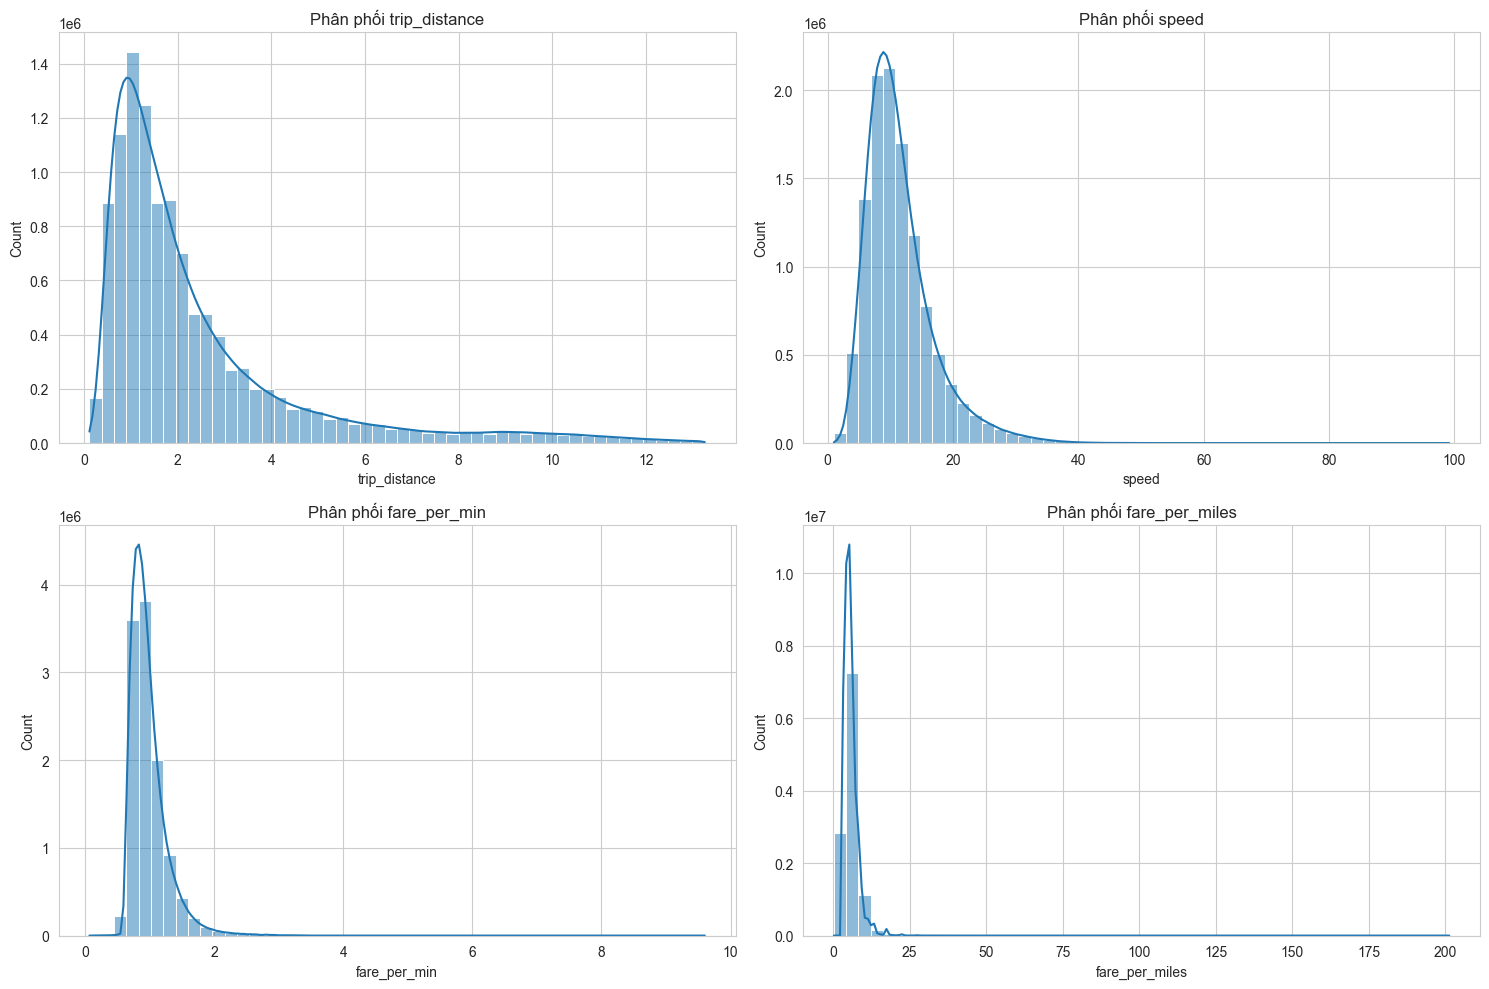

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0,0].set_title('Phân phối trip_distance')
sns.histplot(taxi_df['trip_distance'], ax=ax[0, 0], bins=50, kde=True)

sns.histplot(taxi_df['speed'], ax=ax[0, 1], bins=50, kde=True)
ax[0,1].set_title("Phân phối speed")

sns.histplot(taxi_df.loc[taxi_df['fare_per_min'] < 10, 'fare_per_min'], ax=ax[1,0], bins=50, kde=True)
ax[1,0].set_title("Phân phối fare_per_min")

sns.histplot(taxi_df['fare_per_miles'], ax=ax[1, 1], bins=50, kde=True)
ax[1,1].set_title('Phân phối fare_per_miles')
plt.tight_layout()
plt.show()

### Phân tích phân phối dữ liệu

Từ các biểu đồ phân phối phía trên, ta thấy dữ liệu chuyến taxi tại NYC có sự phân bố rất đa dạng và không đồng nhất.

- Với trip_duration, phần lớn các chuyến đi có thời gian ngắn đến trung bình, tuy nhiên vẫn tồn tại nhiều chuyến có thời gian rất dài tạo thành đuôi phân phối kéo dài.

- Với trip_distance, dữ liệu tập trung chủ yếu ở các chuyến đi ngắn trong nội đô, nhưng vẫn xuất hiện nhiều chuyến đi xa hơn phản ánh các tuyến liên quận hoặc kết nối sân bay.

- Biểu đồ speed cho thấy tốc độ di chuyển của taxi thay đổi đáng kể giữa các chuyến đi. Một số chuyến có tốc độ rất thấp do ảnh hưởng bởi ùn tắc giao thông, trong khi một số chuyến khác có tốc độ cao hơn khi di chuyển trên các tuyến đường ít kẹt xe hoặc cao tốc.

- Đối với fare_per_miles, phần lớn dữ liệu tập trung trong một khoảng nhỏ, tuy nhiên vẫn tồn tại các chuyến có chi phí trên mỗi mile cao bất thường. Điều này phản ánh sự khác biệt giữa các loại chuyến đi như di chuyển trong khu vực đông đúc, sân bay hoặc các tuyến có phụ phí đặc biệt.

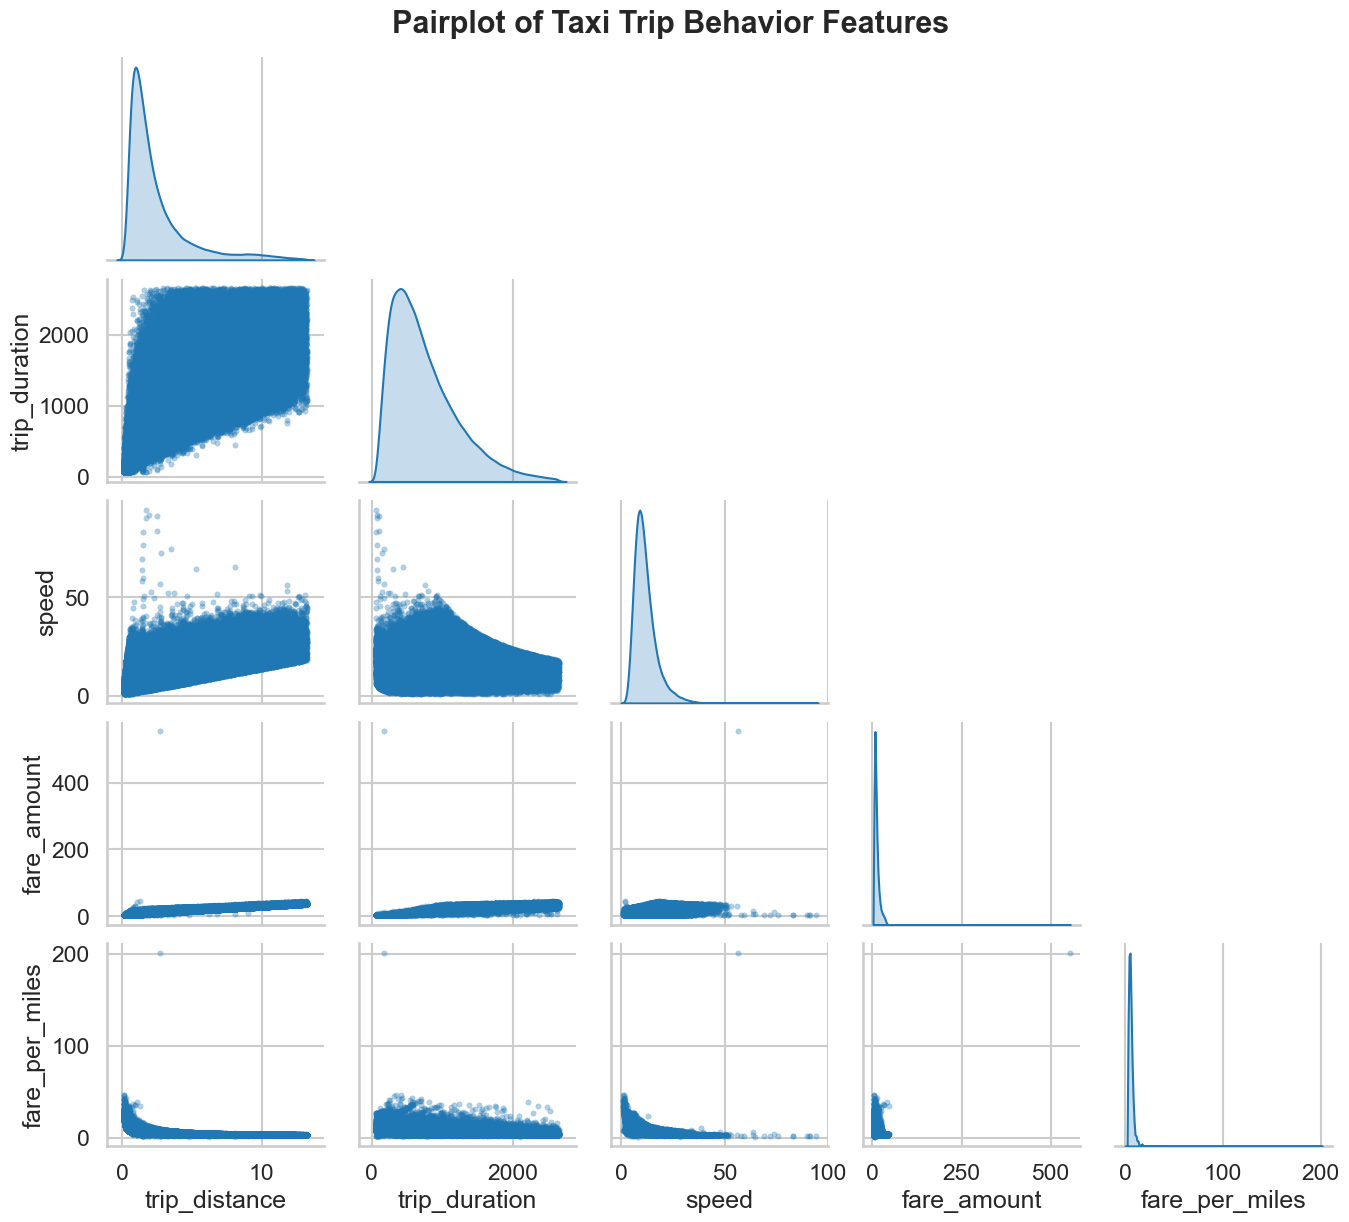

In [17]:
features = ['trip_distance', 'trip_duration', 'speed', 'fare_per_miles']

sample_df = taxi_df.sample(500000, random_state=42)

features = [
    'trip_distance',
    'trip_duration',
    'speed',
    'fare_amount',
    'fare_per_miles'
]

# Style đẹp hơn
sns.set_style("whitegrid")
sns.set_context("talk")

# Pairplot
pair_plot = sns.pairplot(
    sample_df[features],
    
    diag_kind='kde',
    
    corner=True,          # Chỉ hiện nửa dưới cho đỡ rối
    
    plot_kws={
        'alpha': 0.35,
        's': 15,
        'edgecolor': None
    },
    
    diag_kws={
        'fill': True
    
    }
)

# Title
pair_plot.fig.suptitle(
    "Pairplot of Taxi Trip Behavior Features",
    fontsize=22,
    y=1.02,
    fontweight='bold'
)

# Resize figure
pair_plot.fig.set_size_inches(14, 12)

plt.show()

## Thực hiện bài toán

### Tạo thêm feature traffic_level

In [3]:
# traffic_index phản ánh mức độ ùn tắc: thời gian trên mỗi dặm
taxi_df['traffic_index'] = taxi_df['trip_duration'] / (taxi_df['trip_distance'] + 1e-6)

low = taxi_df['traffic_index'].quantile(0.33)
high = taxi_df['traffic_index'].quantile(0.66)

def label_traffic(x):
    if x < low:
        return 0  # low traffic
    elif x < high:
        return 1  # medium traffic
    else:
        return 2  # high traffic

taxi_df['traffic_level'] = taxi_df['traffic_index'].apply(label_traffic)

print('✅ traffic_level created')
print(f'Low threshold  : {low:.2f}')
print(f'High threshold : {high:.2f}')
print('\nTraffic level distribution:')
print(taxi_df['traffic_level'].value_counts().sort_index())
print(f'\nClass ratio:')
print(taxi_df['traffic_level'].value_counts(normalize=True).sort_index().apply(lambda x: f'{x:.2%}'))

✅ traffic_level created
Low threshold  : 288.33
High threshold : 413.22

Traffic level distribution:
traffic_level
0    3765528
1    3766306
2    3880084
Name: count, dtype: int64

Class ratio:
traffic_level
0    33.00%
1    33.00%
2    34.00%
Name: proportion, dtype: object


### Lựa chọn feature cho bài toán và dùng MiniBatchKMeans để lấy K tối ưu

In [4]:
features_input = ['trip_distance', 'traffic_level', 'speed', 'fare_per_miles']

features_scale = ['trip_distance', 'speed', 'fare_per_miles']

scaler = StandardScaler()

X = taxi_df[features_input].copy()

X = pd.get_dummies(X, columns=['traffic_level'])

X[features_scale] = scaler.fit_transform(X[features_scale])

bool_cols = X.select_dtypes(bool).columns
X[bool_cols] = X[bool_cols].astype(int)


sample_size = min(10000, len(X))  
sample_indices = np.random.choice(len(taxi_df), size=sample_size, replace=False)
features_sample = X.iloc[sample_indices]

silhouettes = []
k_range = range(3, 10)
n_components_range = range(2, 4)

for n_components in n_components_range:

    pca = PCA(n_components=n_components)

    X_pca = pca.fit_transform(features_sample[features_scale])

    for k in k_range:
    
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024, n_init=10, max_no_improvement=10)

        labels = kmeans.fit_predict(X_pca)

        score = silhouette_score(X_pca, labels)

        silhouettes.append({ 
            'n_components': n_components,
            'k': k,
            'score': score
        })

        print(f"PCA={n_components} | K={k} | Score={score:.3f}")

results_df = pd.DataFrame(silhouettes)

best_result = results_df.loc[
    results_df['score'].idxmax()
]

PCA=2 | K=3 | Score=0.475
PCA=2 | K=4 | Score=0.445
PCA=2 | K=5 | Score=0.437
PCA=2 | K=6 | Score=0.400
PCA=2 | K=7 | Score=0.408
PCA=2 | K=8 | Score=0.387
PCA=2 | K=9 | Score=0.373
PCA=3 | K=3 | Score=0.406
PCA=3 | K=4 | Score=0.373
PCA=3 | K=5 | Score=0.334
PCA=3 | K=6 | Score=0.347
PCA=3 | K=7 | Score=0.331
PCA=3 | K=8 | Score=0.316
PCA=3 | K=9 | Score=0.328


In [5]:
optimal_k = best_result['k'].astype(int)
optimal_n_components = best_result['n_components'].astype(int)
best_score = best_result['score']

print(f"\nPCA Components tối ưu: {optimal_n_components}")
print(f"K tối ưu: {optimal_k}")
print(f"Silhouette Score tốt nhất: {best_score:.3f}")


PCA Components tối ưu: 2
K tối ưu: 3
Silhouette Score tốt nhất: 0.475


### Sử dụng Kmeans với k tối ưu để dự đoán 

In [13]:
pca = PCA(n_components=optimal_n_components)

X_pca= pca.fit_transform(X)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

taxi_df['behavior_cluster'] = kmeans.fit_predict(X_pca)



print("\nCluster Distribution:")

cluster_counts = (
    taxi_df['behavior_cluster']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


Cluster Distribution:
behavior_cluster
0    3921301
1    6008896
2    1481721
Name: count, dtype: int64


In [14]:
print("\nCluster Mean Analysis:")

analysis_features = [
    'trip_distance',
    'traffic_level',
    'speed',
    'fare_per_miles',
]

cluster_analysis = (
    taxi_df
    .groupby('behavior_cluster')[analysis_features]
    .mean()
    .round(2)
)

display(cluster_analysis)


Cluster Mean Analysis:


,trip_distance,traffic_level,speed,fare_per_miles
behavior_cluster,,,,
0,1.19,1.90,6.83,8.03
1,2.09,0.67,12.20,5.03
2,7.11,0.01,20.81,3.34


### Nhận xét kết quả với K = 3
* Với cluster 0, với traffic_level gần chạm 2 và distance thấp ta có thể thấy đây là cụm với các chuyến taxi trong khu trung tâm thành phố. Với speed thấp và traffic_level phản ánh các chuyến xe này luôn trong tình trạng phải di chuyển chậm có thể là do kẹt xe hay đèn đỏ liên tục. Có thể cụm này là cụm các chuyến đi trong khu trung tâm Manhattan.

* Cluster 1 có các chỉ số khá trung bình với khoảng cách chuyến đi vừa phải, tốc độ ổn định và mức độ giao thông không quá cao. Đây là cụm có số lượng mẫu nhiều nhất, cho thấy phần lớn chuyến xe taxi NYC có hành vi thuộc nhóm hành vi này. Nhóm này phản ánh nhu cầu di chuyển phổ biến của người dân NYC.

* Cluster 2 có distance và speed cao cùng với traffic_level gần chạm 0 cho thấy được các chuyến xe này là các chuyến xe đường dài, có thể là các chuyến đi liên quận hoặc chạy trên các đường cao tốc, hoặc đường lớn ít xe cho nên mới có thể chạy nhanh. Ngoài ra một số chuyến thuộc nhóm này cũng có thể diễn ra trong khung giờ đêm muộn vào lúc tình trạng giao thông thông thoáng nhất.

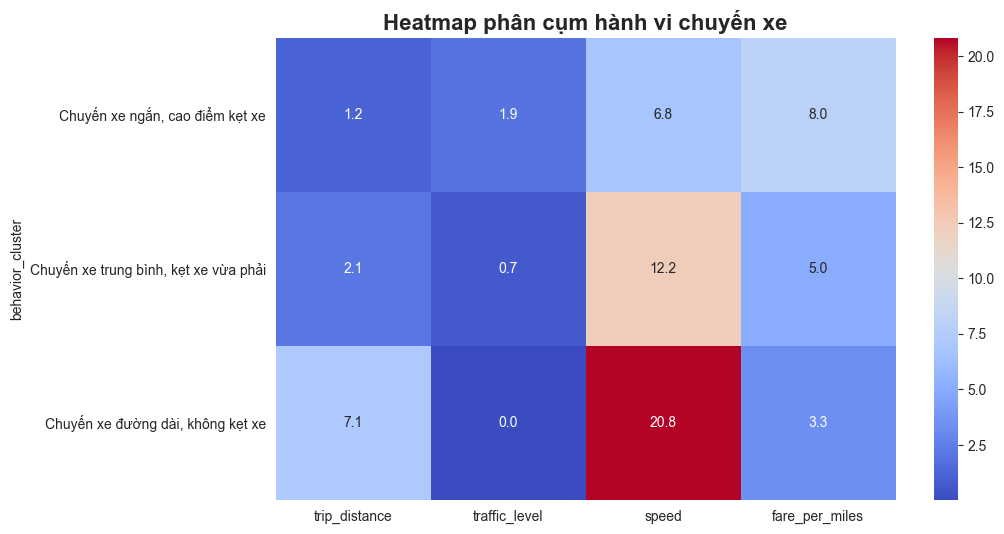

In [18]:
cluster_label = [
    'Chuyến xe ngắn, cao điểm kẹt xe',
    'Chuyến xe trung bình, kẹt xe vừa phải',
    'Chuyến xe đường dài, không kẹt xe'
]

def cluster_heatmap(cluster_label):
    plt.figure(figsize=(10, 6))


    sns.heatmap(
        cluster_analysis,
        annot=True,
        fmt=".1f",
        cmap='coolwarm',
        yticklabels=cluster_label
    )

    plt.title(
        "Heatmap phân cụm hành vi chuyến xe",
        fontsize=16,
        fontweight='bold'
    )
    plt.show()

cluster_heatmap(cluster_label)

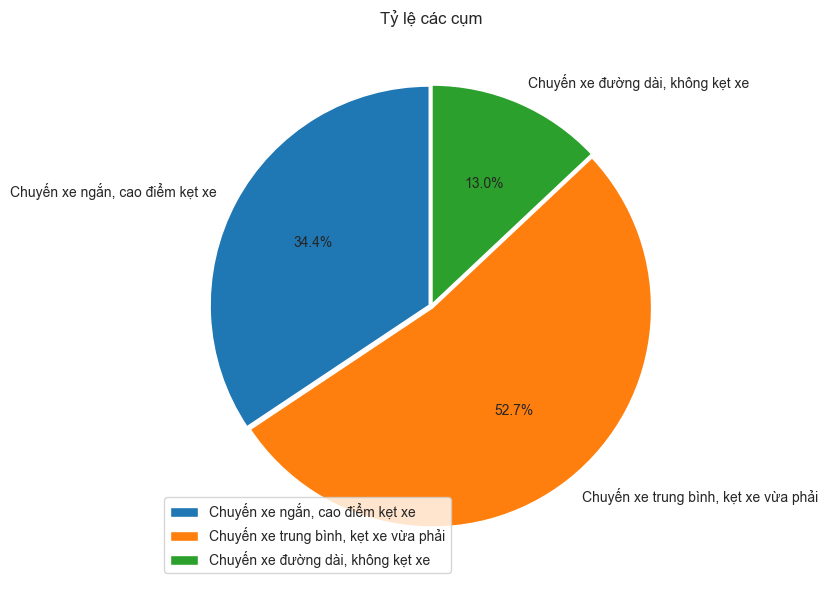

In [ ]:
cluster_percent = (cluster_counts / len(taxi_df)) * 100

explode = [0.01, 0.01, 0.01]

def pie_cluster(cluster_percent, cluster_label, explode):
    plt.pie(
    cluster_percent,
    labels=cluster_label,
    autopct='%1.1f%%',
    startangle=90,
    explode = explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    plt.title("Tỷ lệ các cụm")
    plt.tight_layout()
    plt.show()

pie_cluster(cluster_percent, cluster_label, explode)

### Nhận xét:
* Biểu đồ cho thấy phần lớn chuyến taxi trong thành phố NYC có khoảng cách di chuyển từ ngắn đến trung bình (1 dặm đến 4 dặm), điều này phản ánh nhu cầu di chuyển nội đô là chủ yếu, đặc biệt tại các khu vực đông dân cư và trung tâm thương mại của thành phố.

* Với 34.4% các chuyến taxi luôn phải di chuyển trong tình trạng kẹt xe cho thấy thành phố NYC nói chung (trung tâm Manhattan nói riêng) là một thành phố xô bồ nhộn nhịp và mức độ tắc nghẽn giao thông nghiêm trọng bậc nhất thế giới. Với speed trung bình chỉ 6mph khoảng 9km/h, có thể nói rằng 1 người đi bộ cũng có tốc độ ngang ngửa 1 chiếc taxi chạy trong cao điểm.

### Sử dụng Kmean với K=4, K=5 để so sánh và chọn ra K tối ưu nhất

### Với K=4

In [39]:
pca = PCA(n_components=optimal_n_components)

X_pca= pca.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

taxi_df['behavior_cluster'] = kmeans.fit_predict(X_pca)



print("\nCluster Distribution:")

cluster_counts = (
    taxi_df['behavior_cluster']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


Cluster Distribution:
behavior_cluster
0    3161731
1     872593
2    2596532
3    4781062
Name: count, dtype: int64


In [40]:
print("\nCluster Mean Analysis:")

analysis_features = [
    'trip_distance',
    'traffic_level',
    'speed',
    'fare_per_miles',
]

cluster_analysis = (
    taxi_df
    .groupby('behavior_cluster')[analysis_features]
    .mean()
    .round(2)
)

display(cluster_analysis)


Cluster Mean Analysis:


,trip_distance,traffic_level,speed,fare_per_miles
behavior_cluster,,,,
0,1.10,1.95,6.42,8.44
1,8.65,0.00,23.09,3.17
2,3.35,0.16,15.48,4.08
3,1.69,1.03,10.52,5.57


### Nhận xét kết quả với k=4
* Cluster 0 có trip_distance ngắn và traffic_level cực cao, phản ánh đây là nhóm chuyến xe chạy trong trung tâm đông đúc của thành phố. Speed thấp cho thấy xe taxi luôn trong tình trạng phải đi chậm qua lưu lượng xe tại do tình trạng kẹt xe kéo dài trong trung tâm thành phố. Kéo theo đó thì fare_per_miles sẽ cao lên do thời gian di chuyển được kéo dài.

* Cluster 1 có trip_distance và speed cao nhất trong các cụm cùng với traffic_level gần bằng 0. Cho thấy đây là các chuyến xe đường dài với điều kiện giao thông thông thoáng, chẳng như đi trên cao tốc liên bang, liên quận, hoặc các chuyến đi diễn ra vào ban đêm khi đã bớt. Do đó thời gian di chuyển rất nhanh và ít bị ảnh hưởng bởi kẹt xe cho nên fare_per_miles của nhóm này khá thấp.

* Cluster 2 có trip_distance trung bình nhưng lại có speed khá cao và mức độ giao thông thấp. Cho thấy các chuyến xe của nhóm này có thể xem là các chuyến xe taxi hiệu quả vì hoạt động trong điều kiện giao thông khá thuận lợi. Các chuyến xe này có thể diễn ra ở các vùng khác ngoài trung tâm thành phố và vào các khung giờ ít cao điểm hơn.

* Cluster 3 có các đặc trưng ở mức trung bình từ khoảng cách trung bình, tốc độ vừa phải và điều kiện giao thông không quá kẹt. Đây là nhóm đại diện cho phần lớn các chuyến taxi phổ biến hằng ngày trong NYC với điều kiện giao thông bình thường và không có nhiều đặc điểm gì quá cao như các cụm còn lại.

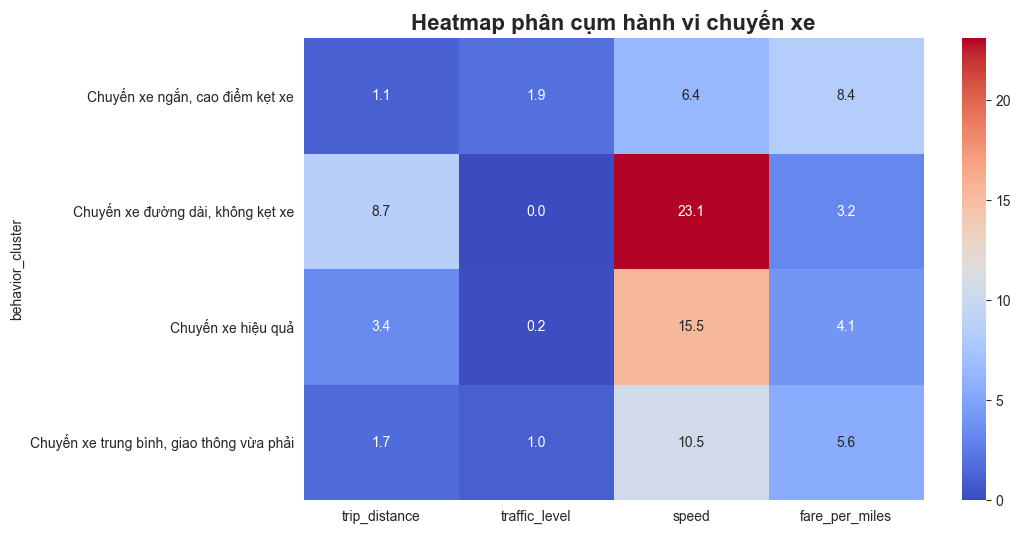

In [41]:
cluster_label = ['Chuyến xe ngắn, cao điểm kẹt xe', 'Chuyến xe đường dài, không kẹt xe', 'Chuyến xe hiệu quả', 'Chuyến xe trung bình, giao thông vừa phải']

cluster_heatmap(cluster_label)

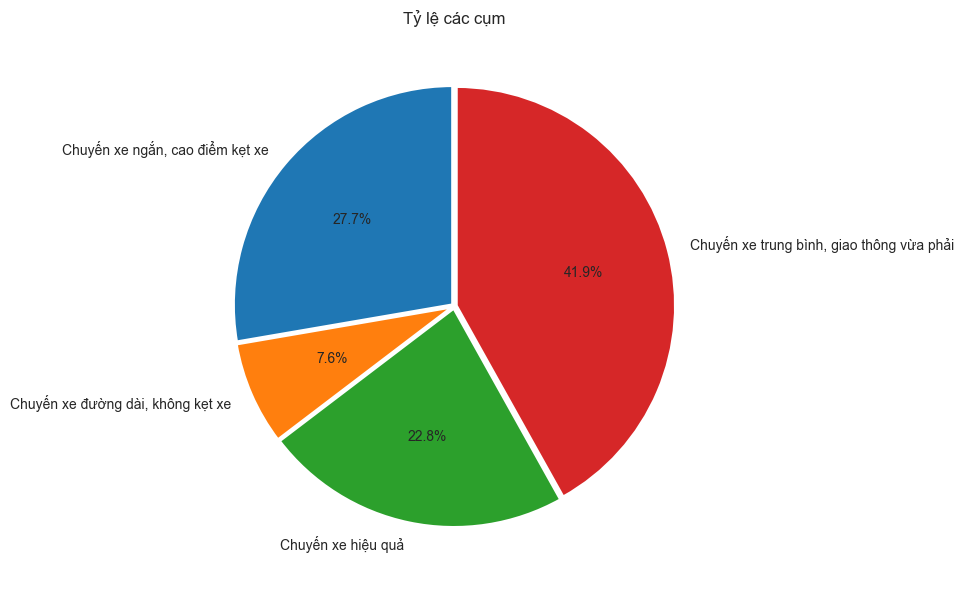

In [42]:
cluster_percent = (cluster_counts / len(taxi_df)) * 100

explode = [0.01, 0.01, 0.01, 0.01]

pie_cluster(cluster_percent, cluster_label, explode)

### Với K=5

In [35]:
pca = PCA(n_components=optimal_n_components)

X_pca= pca.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

taxi_df['behavior_cluster'] = kmeans.fit_predict(X_pca)



print("\nCluster Distribution:")

cluster_counts = (
    taxi_df['behavior_cluster']
    .value_counts()
    .sort_index()
)

print(cluster_counts)


Cluster Distribution:
behavior_cluster
0    3369931
1     837557
2    2375361
3    3981751
4     847318
Name: count, dtype: int64


In [36]:
print("\nCluster Mean Analysis:")

analysis_features = [
    'trip_distance',
    'traffic_level',
    'speed',
    'fare_per_miles',
]

cluster_analysis = (
    taxi_df
    .groupby('behavior_cluster')[analysis_features]
    .mean()
    .round(2)
)

display(cluster_analysis)


Cluster Mean Analysis:


,trip_distance,traffic_level,speed,fare_per_miles
behavior_cluster,,,,
0,1.45,1.88,7.47,6.96
1,8.76,0.00,23.26,3.16
2,3.50,0.14,15.76,4.01
3,1.66,0.80,11.22,5.37
4,0.70,1.98,4.93,11.39


### Nhận xét k=5
* Cluster 0 này vẫn đại diện cho các chuyến đi trong khu vực đông đúc với traffic_level cao và tốc độ thấp. Tuy nhiên mức độ tắc nghẽn cực cao nhưng vẫn chưa đứng đầu trong các cụm. Đây là cụm phản ánh các chuyến xe di chuyển trong nội đô đông đúc nhưng mức độ traffic_level vẫn không cực đoan như Cluster 4

* Cluster 4 có trip_distance rất thấp, traffic_level gần đạt cực đại và speed thấp nhất trong toàn bộ các cụm. Đồng thời fare_per_miles tăng rất cao. Điều này cho thấy đây là các chuyến đi cực ngắn trong khu vực trung tâm thành phố với tình trạng kẹt xe nghiêm trọng hoặc phải dừng chờ nhiều.

* Cluster 1 này tiếp tục đại diện cho các chuyến đi đường dài trên cao tốc hoặc tuyến đường lớn với tốc độ cao và lưu lượng giao thông thấp.

* Cluster 2 này giữ đặc điểm tương tự K = 4 với khoảng cách trung bình, tốc độ khá cao và ít congestion. Đây là đại diện cho nhóm xe di chuyển trong điều kiện thuận lợi

* Cluster 3 vẫn tiếp tục đại diện cho các chuyến đi phổ biến hằng ngày với mức độ giao thông và tốc độ trung bình.


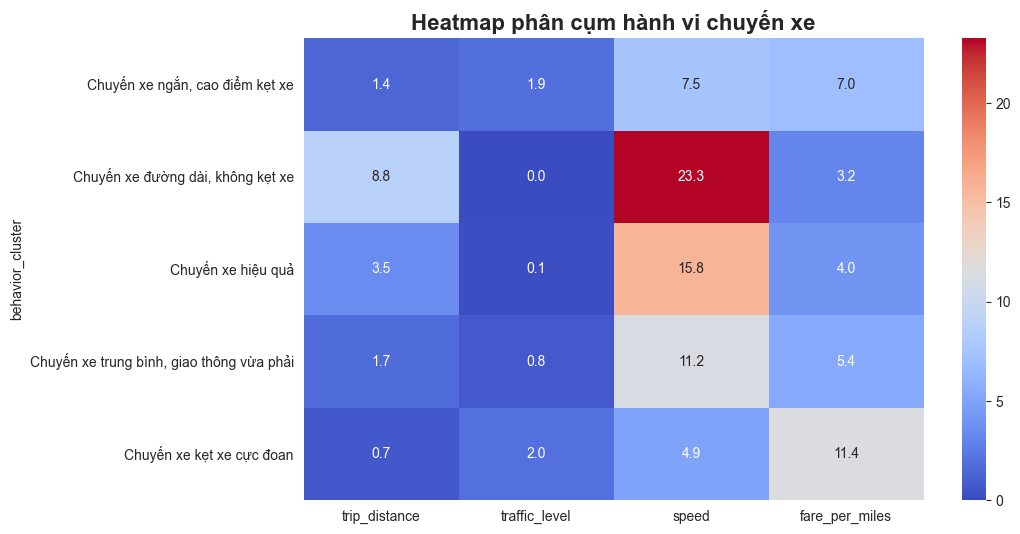

In [37]:
cluster_label = ['Chuyến xe ngắn, cao điểm kẹt xe', 'Chuyến xe đường dài, không kẹt xe', 'Chuyến xe hiệu quả', 'Chuyến xe trung bình, giao thông vừa phải', 'Chuyến xe kẹt xe cực đoan']

cluster_heatmap(cluster_label)

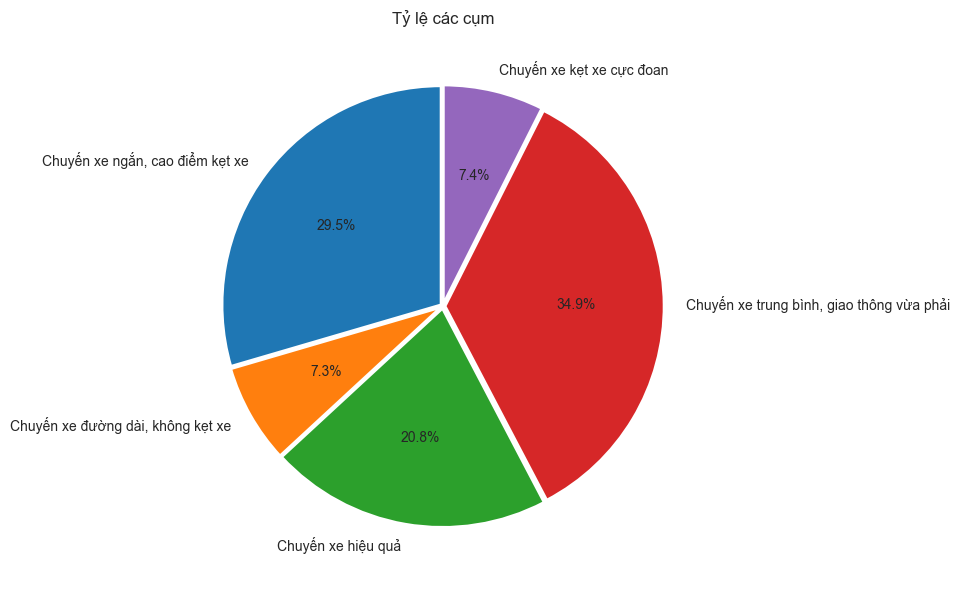

In [38]:
cluster_percent = (cluster_counts / len(taxi_df)) * 100

explode = [0.01, 0.01, 0.01, 0.01, 0.01]

pie_cluster(cluster_percent, cluster_label, explode)

## Tổng kết
* Với K = 3, mô hình đã phân cụm được các nhóm hành vi chuyến taxi tương đối rõ ràng và hợp lý. Ba cụm này đại diện cho ba kiểu hành vi di chuyển phổ biến trong dataset bao gồm: các chuyến đi nội đô kẹt xe, các chuyến đi thông thường trong thành phố và các chuyến đi đường dài với điều kiện giao thông thông thoáng.

* Với K=4 thì Kmeans đã tách rõ dữ liệu 1 cách chi tiết hơn khi tách có thêm 1 cụm cho nhóm taxi thông thường vận hành hiệu quả trong điều kiện giao thông thông thoáng.

* Với K=5 đã phân cụm chi tiết hơn, tuy nhiên tuy nhiên phần lớn sự khác biệt nằm ở việc tách nhỏ thêm nhóm các chuyến đi nội đô đông đúc thành hai mức độ tắc nghẽn khác nhau. Hai cụm 0 và 4 mang ý nghĩa hành vi khá tương đồng và chỉ khác nhau về mức độ nghiêm trọng của ùn tắc giao thông.

### Kết quả k tối ưu nhất:
Sau khi phân tích các kết quả từng K thì nhóm nhận thấy k=4 có các cụm đã thể hiện rõ nhất các nhóm hành vi di chuyển chính của taxi NYC trong thực tế bao gồm:
- Chuyến đi nội đô kẹt xe,
- Chuyến đi đô thị thông thường,
- Chuyến đi hiệu quả trong điều kiện giao thông tốt,
- Chuyến đi đường dài tốc độ cao.

Các cụm ở K = 4 có sự khác biệt rõ ràng hơn về mặt hành vi di chuyển và dễ diễn giải hơn trong thực tế. Vì vậy nhóm quyết định lựa chọn K = 4 nhằm đảm bảo sự cân bằng giữa khả năng phân tách dữ liệu và tính diễn giải của mô hình phân cụm.

### Lấy cluster_behavior làm feature cho các bài toán sau

In [43]:
taxi_df.to_csv('../data/processed/yellow_tripdata_2016-03_processed.csv')